# Tuần 03 — Thực hành kNN: 4 bài

Demo `01_Demo-kNN.ipynb` dừng ở việc **vote nhãn cho một mẫu test**.

Notebook này có **4 bài**. Mỗi bài là một bộ dữ liệu trên Kaggle. Cả 4 bài đều làm.

Viết hàm kNN một lần ở phần chung (NumPy, không dùng `KNeighborsClassifier`), rồi áp vào từng bài. Điền các ô có `???`. Giữ `np.random.seed(3000)`.

Tải đủ 4 file, đặt vào thư mục `data/`:

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Iris Species | https://www.kaggle.com/datasets/uciml/iris | `data/Iris.csv` |
| 2 | Palmer Penguins | https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data | `data/penguins_size.csv` |
| 3 | Heart Failure Prediction | https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction | `data/heart.csv` |
| 4 | Mushroom Classification | https://www.kaggle.com/datasets/uciml/mushroom-classification | `data/mushrooms.csv` |


In [46]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder

np.set_printoptions(precision=3, suppress=True)


## Phần chung — hàm kNN

Các bài bên dưới gọi lại 4 hàm này.

**Chuẩn hóa min–max**, min/max tính trên từng cột của `x_train`, rồi áp cùng hai mốc đó cho `x_test`. Cột nào `max == min` thì giữ nguyên.

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

**Khoảng cách Euclid** từ một mẫu test tới mọi dòng train:

$$
d_i = \sqrt{\sum_j (test_j - train_{i,j})^2}
$$

**Một mẫu:** lấy `K` chỉ số gần nhất (`np.argsort`), vote nhãn xuất hiện nhiều nhất. Hòa thì `np.argmax` trên `counts` chọn nhãn có mã nhỏ hơn.

**Cả tập test:** gọi dự đoán từng mẫu, trả về mảng nhãn cùng độ dài `x_test`.


In [47]:
def chuan_hoa_minmax(x_train, x_test):
    x_min = np.min(x_train, axis=0)
    x_max = np.max(x_train, axis=0)
    x_train_scaled = (x_train - x_min) / (x_max - x_min)
    x_test_scaled = (x_test - x_min) / (x_max - x_min)
    return x_train_scaled, x_test_scaled


def tinh_khoang_cach(test_s, x_train):
    """test_s shape (n_feature,), x_train shape (n_train, n_feature).
    Trả về khoảng cách shape (n_train,).
    """
    kc = np.sqrt(np.sum((x_train - test_s) ** 2, axis=1))
    return kc


def du_doan_1_mau(test_s, x_train, y_train, K):
    kc = tinh_khoang_cach(test_s, x_train)
    idx = np.argsort(kc)[:K]
    y_pred = np.bincount(y_train[idx]).argmax()
    return y_pred


def du_doan_tap(x_test, x_train, y_train, K):
    y_pred = [du_doan_1_mau(test_s, x_train, y_train, K) for test_s in x_test]
    return np.array(y_pred)


In [48]:
def chia_train_test(X, Y, ty_le=0.8, seed=3000):
    np.random.seed(seed)
    rand_indices = np.arange(len(Y))
    np.random.shuffle(rand_indices)
    n_train = int(ty_le * len(Y))
    train_idx = rand_indices[:n_train]
    test_idx = rand_indices[n_train:]
    return X[train_idx], Y[train_idx], X[test_idx], Y[test_idx]


def accuracy(y_pred, y_test):
    return np.mean(y_pred == y_test)


def ve_accuracy_theo_K(x_train, y_train, x_test, y_test, ds_K=None):
    if ds_K is None:
        ds_K = [1, 3, 5, 7, 9, 11, 13, 15]
    ds_acc = [accuracy(du_doan_tap(x_test, x_train, y_train, K), y_test) for K in ds_K]
    print(list(zip(ds_K, np.round(ds_acc, 3))))
    plt.figure(figsize=(6, 4))
    plt.plot(ds_K, ds_acc, marker='o')
    plt.xlabel('K')
    plt.ylabel('accuracy')
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.show()
    return ds_K, ds_acc


---

# Bài 1 — Iris

Nguồn: https://www.kaggle.com/datasets/uciml/iris

File `data/Iris.csv`. 150 bông, 3 loài.

Cột: `Id`, `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`, `Species`.

- Bỏ cột `Id`. Đó là số thứ tự, không phải số đo của hoa.
- Bốn cột đo là số (cm). Nhãn `Species` là chữ: dùng `LabelEncoder`.
- Chuẩn hóa min–max, rồi so sánh accuracy khi **có** và **không** chuẩn hóa (`K=5`).
- In kiểm tra mẫu test đầu tiên (khoảng cách K láng giềng, nhãn của họ, nhãn đoán, nhãn thật), rồi vẽ accuracy theo K.


In [122]:
raw_iris = np.genfromtxt('data/Iris.csv', delimiter=',', dtype=str, skip_header=1)
print(raw_iris.shape)
print(raw_iris[0])

# TODO: X_iris float (bỏ Id), Y_iris int
X_iris = raw_iris[:, 1:5].astype(float)
Y_iris = LabelEncoder().fit_transform(raw_iris[:, 5])

print(X_iris.shape, Y_iris.shape)
print(np.unique(Y_iris, return_counts=True))


(150, 6)
['1' '5.1' '3.5' '1.4' '0.2' 'Iris-setosa']
(150, 4) (150,)
(array([0, 1, 2]), array([50, 50, 50]))


K khoảng cách nhỏ nhất: [ 85  81 117  71  87]
nhãn K láng giềng: [2 2 2 2 2]
nhãn dự đoán: 2
nhãn thực tế: 2
accuracy K=5, đã chuẩn hóa: 0.967
accuracy K=5, chưa chuẩn hóa: 0.967
[(1, np.float64(0.967)), (3, np.float64(0.967)), (5, np.float64(0.967)), (7, np.float64(0.967)), (9, np.float64(0.967)), (11, np.float64(0.967)), (13, np.float64(0.967)), (15, np.float64(0.967))]


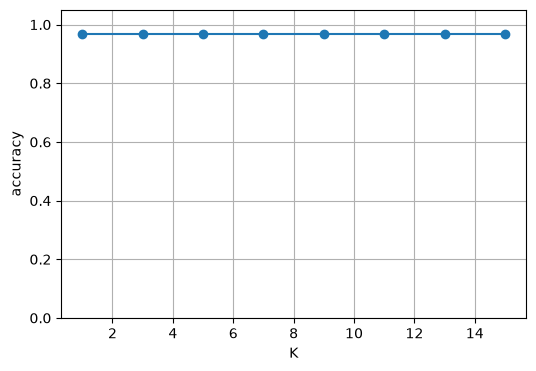

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667)])

In [123]:
x_train, y_train, x_test, y_test = chia_train_test(X_iris, Y_iris)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

K = 5
# TODO: in K khoảng cách nhỏ nhất, nhãn K láng giềng, nhãn dự đoán, y_test[0]
print('K khoảng cách nhỏ nhất:', np.argsort(tinh_khoang_cach(x_test_s[0], x_train_s))[:K])
print('nhãn K láng giềng:', y_train[np.argsort(tinh_khoang_cach(x_test_s[0], x_train_s))[:K]])
print('nhãn dự đoán:', du_doan_1_mau(x_test_s[0], x_train_s, y_train, K))
print('nhãn thực tế:', y_test[0])

print('accuracy K=5, đã chuẩn hóa:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, K), y_test).round(3))
print('accuracy K=5, chưa chuẩn hóa:', accuracy(du_doan_tap(x_test, x_train, y_train, K), y_test).round(3))

ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 1**

1. `X` có bao nhiêu dòng, bao nhiêu cột? Có bao nhiêu lớp?
2. Accuracy tại `K=5` khi có chuẩn hóa và khi không chuẩn hóa chênh nhau thế nào? Vì sao với Iris mức chênh thường nhỏ?
3. Vì sao không đưa cột `Id` vào feature?


In [51]:
# Bài 1
# 1. X có 150 dòng, 4 cột và Có 3 lớp.
# 2. Accuracy tại K=5 khi có chuẩn hóa và không chuẩn hóa là bằng nhau, đều bằng 0.967.
# Với tập dữ liệu Iris mức chênh thường rất nhỏ hoặc không có vì 4 đặc trưng đo lường đều dùng chung đơn vị (cm) và có dãy giá trị khá tương đồng. Do đó, khoảng cách Euclid tương đối giữa các điểm dữ liệu không bị thay đổi quá nhiều dù có chuẩn hóa hay không.
# 3. Không đưa cột Id vào feature vì đó chỉ là số thứ tự, không phải là thông số đo của hoa. Nếu thêm vào sẽ gây nhiễu cho mô hình, làm giảm độ chính xác của dự đoán.

---

# Bài 2 — Palmer Penguins

Nguồn: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

File `data/penguins_size.csv`. Đoán loài chim cánh cụt.

Cột: `species`, `island`, `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`, `sex`.

- Bỏ mọi dòng có ô trống hoặc `NA`.
- Nhãn là `species`.
- `island` và `sex` là chữ: `LabelEncoder` **từng cột**.
- Bốn cột đo là số: `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`.
- Bắt buộc chuẩn hóa. `body_mass_g` khoảng vài nghìn, chiều dài mỏ khoảng vài chục. Không chuẩn hóa thì khoảng cách gần như chỉ còn khối lượng.


In [128]:
raw_pen = np.genfromtxt('data/penguins_size.csv', delimiter=',', dtype=str, skip_header=1)
print('trước khi bỏ dòng thiếu:', raw_pen.shape)

# TODO: bỏ dòng có '' hoặc 'NA', rồi tạo X_pen (float) và Y_pen (int)
raw_pen = raw_pen[np.all((raw_pen != '') & (raw_pen != 'NA'), axis=1)]
Y_pen = LabelEncoder().fit_transform(raw_pen[:, 0])
island_encoded = LabelEncoder().fit_transform(raw_pen[:, 1])
sex_encoded = LabelEncoder().fit_transform(raw_pen[:, 6])
X_pen = np.column_stack([island_encoded, sex_encoded, raw_pen[:, 2:6].astype(float)])

print('sau khi bỏ dòng thiếu:', X_pen.shape, Y_pen.shape)
print(np.unique(Y_pen, return_counts=True))


trước khi bỏ dòng thiếu: (344, 7)
sau khi bỏ dòng thiếu: (334, 6) (334,)
(array([0, 1, 2]), array([146,  68, 120]))


accuracy K=5, đã chuẩn hóa: 0.9552238805970149
accuracy K=5, chưa chuẩn hóa: 0.7611940298507462
[(1, np.float64(0.985)), (3, np.float64(0.97)), (5, np.float64(0.955)), (7, np.float64(0.97)), (9, np.float64(0.97)), (11, np.float64(0.97)), (13, np.float64(0.97)), (15, np.float64(0.985))]


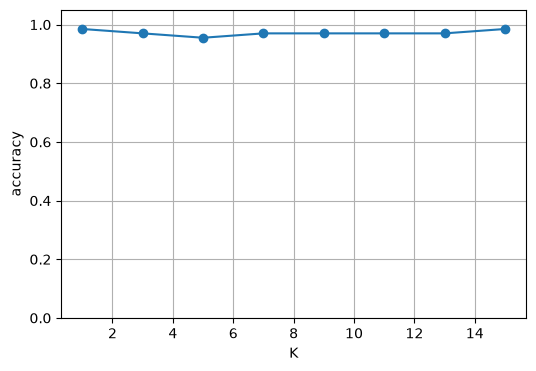

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.9850746268656716),
  np.float64(0.9701492537313433),
  np.float64(0.9552238805970149),
  np.float64(0.9701492537313433),
  np.float64(0.9701492537313433),
  np.float64(0.9701492537313433),
  np.float64(0.9701492537313433),
  np.float64(0.9850746268656716)])

In [130]:
x_train, y_train, x_test, y_test = chia_train_test(X_pen, Y_pen)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

print('accuracy K=5, đã chuẩn hóa:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, 5), y_test))
print('accuracy K=5, chưa chuẩn hóa:', accuracy(du_doan_tap(x_test, x_train, y_train, 5), y_test))

ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 2**

1. Bỏ bao nhiêu dòng vì thiếu dữ liệu?
2. Accuracy `K=5` khi chưa chuẩn hóa thấp hơn bản đã chuẩn hóa ra sao? Cột nào kéo khoảng cách Euclid?
3. `K` nào cho accuracy cao nhất trên đồ thị?


In [ ]:
# Bài 2
# 1. Bỏ 10 dòng vì thiếu dữ liệu.
# 2. Tại K=5, accuracy khi chưa chuẩn hóa (khoảng 0.761) thấp hơn bản đã chuẩn hóa (khoảng 0.955). Cột kéo khoảng cách Euclid chính là cột body_mass_g vì giá trị của nó lên tới hàng nghìn.
# 3. K=1, K=15 cho accuracy cao nhất trên đồ thị.


---

# Bài 3 — Heart Failure Prediction

Nguồn: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

File `data/heart.csv`. 918 dòng. Đoán có bệnh tim hay không. Cùng kiểu bài với demo tình trạng xe.

Cột theo đúng thứ tự trong file:

`Age`, `Sex`, `ChestPainType`, `RestingBP`, `Cholesterol`, `FastingBS`, `RestingECG`, `MaxHR`, `ExerciseAngina`, `Oldpeak`, `ST_Slope`, `HeartDisease`.

- Nhãn `HeartDisease` đã là `0` / `1`.
- Cột chữ, `LabelEncoder` từng cột: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.
- Cột số: `Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`.
- Ghép các cột đã mã hóa thành một ma trận `X` kiểu float, rồi chuẩn hóa min–max.
- Hai lớp, nên các `K` đem thử là số lẻ.


In [132]:
raw_heart = np.genfromtxt('data/heart.csv', delimiter=',', dtype=str, skip_header=1)
print(raw_heart.shape)
print(raw_heart[0])

# TODO: X_heart float, Y_heart int
Sex_encoded = LabelEncoder().fit_transform(raw_heart[:, 1])
ChestPainType_encoded = LabelEncoder().fit_transform(raw_heart[:, 2])
RestingECG_encoded = LabelEncoder().fit_transform(raw_heart[:, 6])
ExerciseAngina_encoded = LabelEncoder().fit_transform(raw_heart[:, 8]) 
ST_Slope_encoded = LabelEncoder().fit_transform(raw_heart[:, 10])
X_heart = np.column_stack([raw_heart[:, 0],Sex_encoded,ChestPainType_encoded, raw_heart[:, 3:6],RestingECG_encoded, raw_heart[:, 7],ExerciseAngina_encoded, raw_heart[:, 9], ST_Slope_encoded]).astype(float)
Y_heart = raw_heart[:, -1].astype(int)

print(X_heart.shape, Y_heart.shape)
print(np.unique(Y_heart, return_counts=True))


(918, 12)
['40' 'M' 'ATA' '140' '289' '0' 'Normal' '172' 'N' '0' 'Up' '0']
(918, 11) (918,)
(array([0, 1]), array([410, 508]))


accuracy K=5: 0.875
[(1, np.float64(0.87)), (3, np.float64(0.886)), (5, np.float64(0.875)), (7, np.float64(0.87)), (9, np.float64(0.87)), (11, np.float64(0.864)), (13, np.float64(0.87)), (15, np.float64(0.853))]


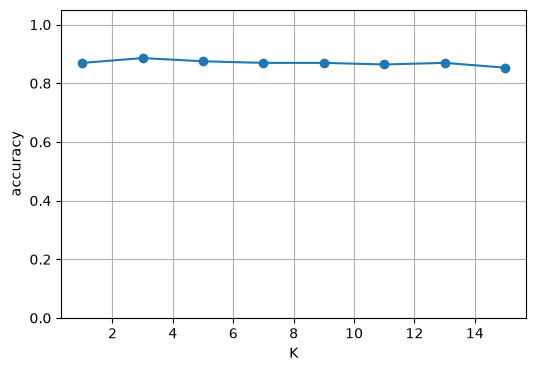

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.8695652173913043),
  np.float64(0.8858695652173914),
  np.float64(0.875),
  np.float64(0.8695652173913043),
  np.float64(0.8695652173913043),
  np.float64(0.8641304347826086),
  np.float64(0.8695652173913043),
  np.float64(0.8532608695652174)])

In [133]:
x_train, y_train, x_test, y_test = chia_train_test(X_heart, Y_heart)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

print('accuracy K=5:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, 5), y_test))
ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 3**

1. Có bao nhiêu người trong tập test? Tỉ lệ lớp `0` và `1` trên toàn bộ dữ liệu là bao nhiêu?
2. Accuracy cao nhất và `K` tương ứng?
3. Vì sao với bài 2 lớp nên chọn `K` lẻ?


In [ ]:
# Bài 3
# 1. Có 918 người trong tập test. Tỉ lệ lớp 0 và lớp 1 lần lượt là 0.45 và 0.55, trong đó lớp 0 410 mẫu, lớp 1 508 mẫu.
# 2. Accuracy cao nhất là 0.8859 tại K=3.
# 3. Với bài toán phân loại 2 lớp, nên chọn K lẻ vì giúp tránh hoàn toàn hiện tượng hòa phiếu (tie voting) khi bầu chọn đa số (ví dụ chọn K chẵn như 4 có thể xảy ra tỉ lệ 2-2), đảm bảo luôn có một lớp chiếm đa số rõ rệt để đưa ra kết quả dự đoán.


---

# Bài 4 — Mushroom Classification

Nguồn: https://www.kaggle.com/datasets/uciml/mushroom-classification

File `data/mushrooms.csv`. Đoán nấm ăn được (`e`) hay độc (`p`).

Mọi cột đều là chữ, cùng kiểu demo xe. Cột 0 là nhãn `class`. Các cột còn lại là feature.

- Bỏ dòng nào còn giá trị `?`.
- `LabelEncoder` **từng cột** feature, rồi mã hóa riêng cột nhãn. Giống đoạn mã hóa trong demo xe.
- **Không** chuẩn hóa min–max. Mã `LabelEncoder` chỉ là tên nhóm được đánh số, không phải số đo cùng đơn vị.
- Tập này vài nghìn dòng. `tinh_khoang_cach` cần tính một lần cho cả `x_train` (vector), không viết vòng `for` từng dòng train.


In [134]:
raw_mush = np.genfromtxt('data/mushrooms.csv', delimiter=',', dtype=str, skip_header=1)
print('trước khi bỏ dòng có ?:', raw_mush.shape)

# TODO: bỏ dòng chứa '?', X_mush float, Y_mush int
raw_mush = raw_mush[np.all(raw_mush != '?', axis=1)]
LE = LabelEncoder()
Y_mush = LabelEncoder().fit_transform(raw_mush[:, 0])
X_mush = np.stack([LE.fit_transform(col) for col in raw_mush[:, 1:].T], axis=1).astype(float)

print(X_mush.shape, Y_mush.shape)
print(np.unique(Y_mush, return_counts=True))


trước khi bỏ dòng có ?: (8124, 23)
(5644, 22) (5644,)
(array([0, 1]), array([3488, 2156]))


accuracy K=5: 0.9991142604074402
[(1, np.float64(1.0)), (3, np.float64(1.0)), (5, np.float64(0.999)), (7, np.float64(0.999)), (9, np.float64(0.998)), (11, np.float64(0.997)), (13, np.float64(0.996)), (15, np.float64(0.996))]


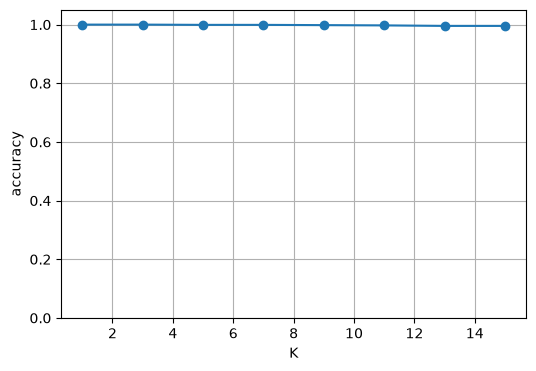

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(1.0),
  np.float64(1.0),
  np.float64(0.9991142604074402),
  np.float64(0.9991142604074402),
  np.float64(0.9982285208148804),
  np.float64(0.9973427812223207),
  np.float64(0.995571302037201),
  np.float64(0.995571302037201)])

In [135]:
x_train, y_train, x_test, y_test = chia_train_test(X_mush, Y_mush)

# Không gọi chuan_hoa_minmax
print('accuracy K=5:', accuracy(du_doan_tap(x_test, x_train, y_train, 5), y_test))
ve_accuracy_theo_K(x_train, y_train, x_test, y_test)


**Nộp kèm bài 4**

1. Còn bao nhiêu dòng sau khi bỏ `?`? Bao nhiêu feature?
2. Accuracy cao nhất và `K` tương ứng?
3. Bài này giống demo tình trạng xe ở bước nào, và khác bài 1–3 ở chỗ nào (chuẩn hóa)?


In [ ]:
# Bài 4
# 1. Còn 5644 dòng sau khi bỏ "?". Có 22 feature
# 2. Accuracy cao nhất là 1.0 tại K=1, K=3
# 3. Bài này giống demo tình trạng xe ở chỗ toàn bộ các cột đặc trưng đều là dạng chữ. Bài này khác các bài 1–3 ở chỗ không thực hiện chuẩn hóa min–max, vì các giá trị mã hóa chỉ là định danh danh mục chứ không phải là số đo vật lý có đơn vị
